<a href="https://www.kaggle.com/code/nityaverma19/netflix-prize?scriptVersionId=167027100" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-prize-data/combined_data_3.txt
/kaggle/input/netflix-prize-data/movie_titles.csv
/kaggle/input/netflix-prize-data/combined_data_4.txt
/kaggle/input/netflix-prize-data/combined_data_1.txt
/kaggle/input/netflix-prize-data/README
/kaggle/input/netflix-prize-data/probe.txt
/kaggle/input/netflix-prize-data/combined_data_2.txt
/kaggle/input/netflix-prize-data/qualifying.txt


In [2]:
# Defining column names
column_names = ['MovieID', 'YearOfRelease', 'Title']

# Reading CSV file without headers, skipping lines with parsing errors
movie_titles = pd.read_csv('/kaggle/input/netflix-prize-data/movie_titles.csv', encoding='ISO-8859-1', header=None, names=column_names,on_bad_lines ='skip')

# Display the first few rows of the dataframe
movie_titles.head(10)

,MovieID,YearOfRelease,Title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
6,7,1992.0,8 Man
7,8,2004.0,What the #$*! Do We Know!?
8,9,1991.0,Class of Nuke 'Em High 2
9,10,2001.0,Fighter


Txt to df -  combined data 1

In [3]:
import pandas as pd

def read_combined_data(file_path):
    # Initialize lists to store data
    movie_ids = []
    customer_ids = []
    ratings = []
    dates = []

    # Read the file
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize variables
    current_movie_id = None

    # Process each line
    for line in lines:
        # Strip leading/trailing whitespaces
        line = line.strip()

        # Check for movie ID
        if line.endswith(':'):
            # Update current movie ID
            current_movie_id = line[:-1].strip()
        elif line:  # Check if the line is not empty
            # Extract customer data
            data = line.strip().split(',')
            if len(data) >= 3:
                customer_id = data[0].strip()
                rating_str = data[1].strip()
                date = data[2].strip()

                try:
                    rating = float(rating_str)
                except ValueError:
                    print(f"Skipping invalid rating (not a valid float): '{rating_str}'")
                    continue

                # Append data to lists
                movie_ids.append(current_movie_id)
                customer_ids.append(customer_id)
                ratings.append(rating)
                dates.append(date)
            else:
                print(f"Skipping line with insufficient data: '{line}'")

    # Create DataFrame
    combined_data = pd.DataFrame({
        'MovieID': movie_ids,
        'CustomerID': customer_ids,
        'Rating': ratings,
        'Date': dates
    })

    return combined_data

# Read combined_data_1.txt
file_path = "/kaggle/input/netflix-prize-data/combined_data_1.txt"
print(f"Reading file: {file_path}")
data_1 = read_combined_data(file_path)

# Display the first few rows of the DataFrame
print(data_1.head())

Reading file: /kaggle/input/netflix-prize-data/combined_data_1.txt
  MovieID CustomerID  Rating        Date
0       1    1488844     3.0  2005-09-06
1       1     822109     5.0  2005-05-13
2       1     885013     4.0  2005-10-19
3       1      30878     4.0  2005-12-26
4       1     823519     3.0  2004-05-03


In [4]:
data_1.head(5)

,MovieID,CustomerID,Rating,Date
0,1,1488844,3.0,2005-09-06
1,1,822109,5.0,2005-05-13
2,1,885013,4.0,2005-10-19
3,1,30878,4.0,2005-12-26
4,1,823519,3.0,2004-05-03


txt to df- combined data 2



In [5]:
data_1.drop(columns = "Date", inplace = True)

In [6]:
data_1.head()

,MovieID,CustomerID,Rating
0,1,1488844,3.0
1,1,822109,5.0
2,1,885013,4.0
3,1,30878,4.0
4,1,823519,3.0


**Viewing the Data**

*Total movies*

In [7]:
movie_titles.shape

(17434, 3)

Total movies - 17434

*Total ratings in combined_data_1*

In [8]:
data_1.shape

(24053764, 3)

*Total movies in data_1*

In [9]:
data_1['MovieID'].tail(1)

24053763    4499
Name: MovieID, dtype: object

4499 movies rated in data_1

*Total ratings for movie*

In [10]:
data_1[data_1['MovieID'] == '1'].shape

(547, 3)

547 ratings for movie 1

*Dropping year of release*

***Changing the data type of rating***

In [11]:
data_1['Rating']=data_1['Rating'].astype("int8")

***Unique users and movies***

In [12]:
data_1['CustomerID'].nunique()

470758

In [13]:
data_1['MovieID'].nunique()

4499

# **------------------------------------------------------------------------------------------------------------------------------------------------**

## **DATA CLEANING**

### **Missing Values**

In [14]:
movie_titles.isnull().sum()

MovieID          0
YearOfRelease    7
Title            0
dtype: int64

*no missing values in movie titles dataset*

In [15]:
data_1.isnull().sum()

MovieID       0
CustomerID    0
Rating        0
dtype: int64

*No missing values in the data_1*

### **Duplicates**

***Movie titles dataset*** 

In [16]:
movie_titles.duplicated().sum()

0

*No duplicated movies found*

In [17]:
data_1.head()

,MovieID,CustomerID,Rating
0,1,1488844,3
1,1,822109,5
2,1,885013,4
3,1,30878,4
4,1,823519,3


***Any user who has rated the same movie more than once***

In [18]:
data_1.groupby(['MovieID', 'CustomerID']).count()

Rating
MovieID CustomerID        
1       1001779          1
        1005769          1
        1008986          1
        1009622          1
        1011918          1
...                    ...
999     984474           1
        98676            1
        995497           1
        997271           1
        999528           1

[24053764 rows x 1 columns]

In [19]:
data_1.groupby(['MovieID', 'CustomerID']).count()['Rating'].sum()

24053764

*No one user has rated the movie movie more than once*

***Maximum and minimum values of rating***

In [20]:
print("max",data_1['Rating'].max())
print("min",data_1['Rating'].min())

max 5
min 1


### **-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

# *Collaborative Filtering*

In [21]:
import seaborn as sns

### *User criteria-*

In [22]:
count_of_ratings = data_1.groupby('CustomerID').count()['MovieID'].mode()
count_of_ratings

0    2
Name: MovieID, dtype: int64

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='MovieID', ylabel='Count'>

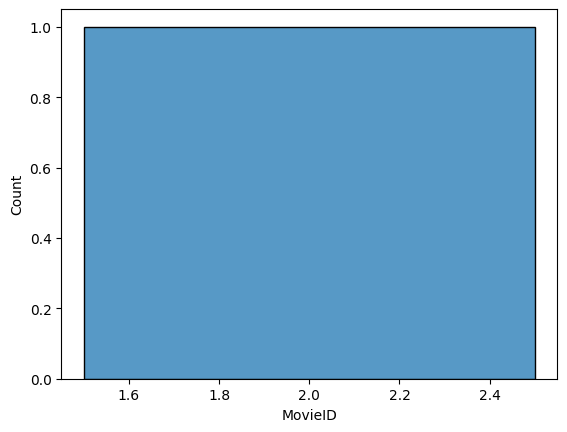

In [23]:
sns.histplot(count_of_ratings)